# **Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)**
Creen un Jupyter Notebook nuevo, carguen el dataset proporcionado en GitHub y seleccionen a su "Jugador Estrella" (puede ser el jugador con más goles o su favorito del dataset, la decisión es suya).

**Misión:**
1. Construyan la matriz multidimensional X seleccionando al menos 4 características numéricas (pueden ser más) continuas (float) que definan el rendimiento del jugador (por ejemplo: Goles, Asistencias, Minutos_Jugados, Precisión_Pases, Recuperaciones, etc.).
2. Creen un vector para su jugador estrella y otro vector para el resto de los candidatos.
3. Pregunta de control: Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)? Apliquen esa transformación en el código.

**Respuesta:** Se debe estandarizar con z-score para evitar que la distancia se vea dominada por los minutos jugados. Con esto cada columan queda con media 0 y desviación estándar 1, por lo que todas contribuyen de forma comparable a la distancia total. 

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/players_data-2025_2026.csv")
df_matrix = df[["Age", "MP", "Min", "Gls", "Ast"]]

# Estandarización Z-Score
df_matrix = (df_matrix - df_matrix.mean()) / df_matrix.std()

# Jugador Estrella: Giuseppe Ambrosino (no se quien es)
# 21 3 38 0 0
star_player = df[df["Player"] == "Giuseppe Ambrosino"]
star_player = df_matrix.loc[star_player.index]
print(star_player)
df = df.drop(index=star_player.index)
other_players = df_matrix.drop(index=star_player.index)

         Age        MP       Min       Gls      Ast
99 -0.833912 -1.400889 -1.225661 -0.566185 -0.63239


# **Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)**
La distancia euclidiana (la línea recta) no es la única forma de viajar por el espacio vectorial. Existen otras métricas como la Distancia Manhattan (Norma L1), que calcula la distancia moviéndose estrictamente en ángulos rectos, como si un taxi navegara por las cuadras de Nueva York, también es conocida como la distancia del taxista.

**Misión:**
1. Investiguen y escriban en su Notebook la fórmula matemática de la Distancia Manhattan.

*La fórmula matemática de la distancia de Manhattan entre dos puntos P_1 = (x_1, y_1) y P_2 = (x_2, y_2) en un plano bidimensional es |x_2 - x_1| + |y_2 - y_1|.*

2. Programen una celda para encontrar al jugador más similar a su estrella usando la Distancia Euclidiana. Impriman el nombre del reemplazo sugerido.
3. En la siguiente celda, busquen al reemplazo calculando la Distancia Manhattan (deberán generar una función custom para calcular esta distancia).
4. Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.

**Respuesta:** En este caso si sugirió al mismo jugador y la distancia es exactamente la misma. Al ver el dataset, pude encontrar que los valores que escogí de mi jugador estrella y los del reemplazo son los mismos excepto en una columna y ahí la diferencia es de 1. Por lo tanto, no es tan extraño que hayan devuelto la misma distancia. Aunque las diferencias entre ellas están en la euclidiana siempre es igual o más corta a la de Manhattan, ya que es diagonal, mientras que la de Manhattan solo va en horizontal y vertical, como si se camninara por cuadras. 

In [44]:
distances_e = other_players.values - star_player.values 

def manhattan_distance(v1, v2):
    return np.abs(v1 - v2).sum(axis=1)

distances_m = manhattan_distance(other_players.values, star_player.values)

other_players["Distance_E"] = np.sqrt((distances_e ** 2).sum(axis=1))
replacement_e = other_players.sort_values("Distance_E").iloc[0]

other_players["Distance_M"] = distances_m
replacement_m = other_players.sort_values("Distance_M").iloc[0]

print("El jugador más parecido según distancia euclidiana es:", df["Player"].loc[replacement_e.name], replacement_e["Distance_E"])
print("El jugador más parecido según distancia Manhattan es:", df["Player"].loc[replacement_m.name], replacement_m["Distance_M"])

El jugador más parecido según distancia euclidiana es: Jan Urbich 0.0010381855072107982
El jugador más parecido según distancia Manhattan es: Jan Urbich 0.0010381855072107982


# **Fase 3: El Reto de Visualización en 4D (Investigación Independiente)**
El director técnico quiere ver un reporte visual de por qué el jugador que sugirieron es el más parecido al original.
El problema físico es que ustedes seleccionaron 4 (o más) características. Los seres humanos solo podemos ver un eje X, un eje Y y un eje Z.

**Misión de Investigación:**
1. Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.(Pistas que pueden investigar: Gráficos de Radar / Spider Charts, Coordenadas Paralelas, o el uso de color/tamaño como cuartas dimensiones en un Scatter 3D).
2. Implementen el código para visualizar a su "Jugador Estrella" junto al "Reemplazo Sugerido" y a un "Tercer Jugador Aleatorio" (para ver el contraste).
3. Entreguen el Notebook documentado comprobando visualmente que los vectores de su estrella y su clon están, efectivamente, muy cerca en el hiperespacio.

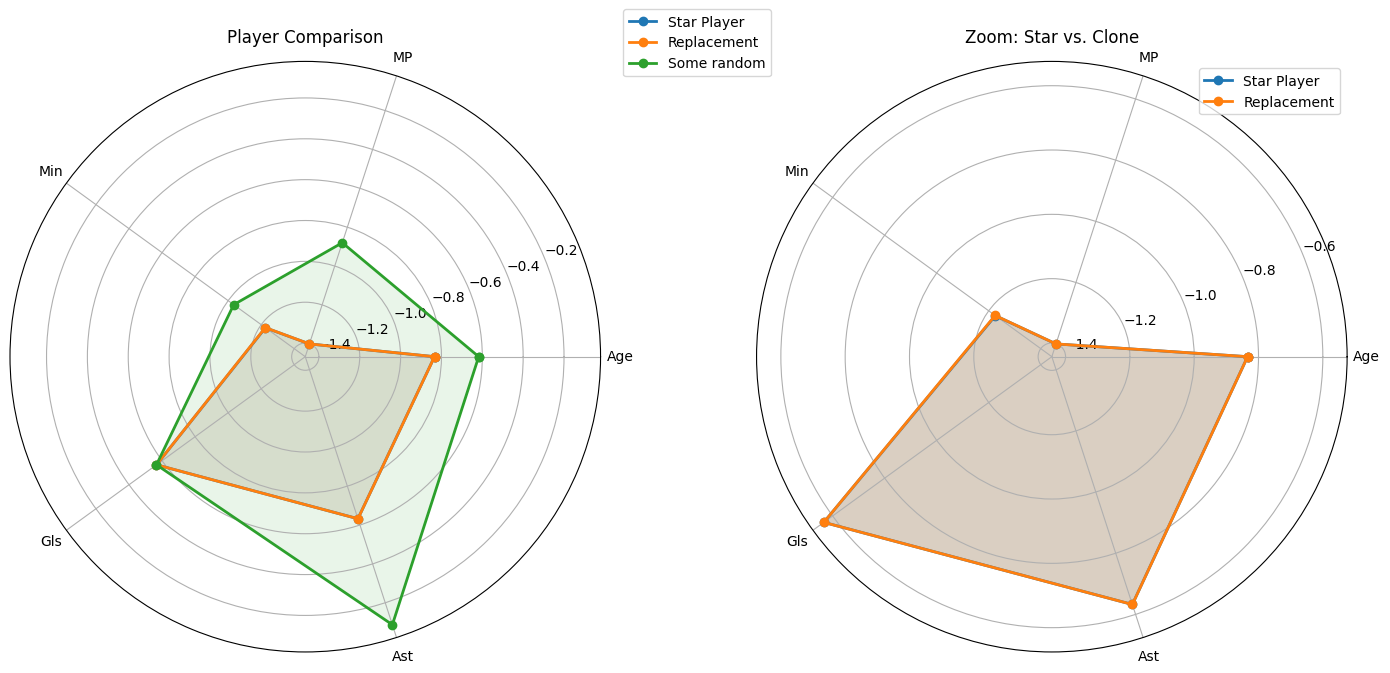

In [ ]:
cols = ["Age", "MP", "Min", "Gls", "Ast"]

# random player
random_idx = other_players.drop(index=replacement_e.name).sample(1, random_state=42).index[0]
random_player_vector = other_players.loc[random_idx, cols].values

star_vector = star_player.values.flatten()
clone_vector = other_players.loc[replacement_e.name, cols].values

players = {
    "Star Player": star_vector,
    "Replacement": clone_vector,
    "Some random": random_player_vector,
}

n_cols = len(cols)
degs = np.linspace(0, 2 * np.pi, n_cols, endpoint=False).tolist()
degs += degs[:1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), subplot_kw=dict(polar=True))

for name, vector in players.items():
    values = list(vector) + [vector[0]]
    ax1.plot(degs, values, linewidth=2, marker='o', label=name)
    ax1.fill(degs, values, alpha=0.1)

for name in ["Star Player", "Replacement"]:
    values = list(players[name]) + [players[name][0]]
    ax2.plot(degs, values, linewidth=2, marker='o', label=name)
    ax2.fill(degs, values, alpha=0.2)

ax1.set_xticks(degs[:-1])
ax1.set_xticklabels(cols)
ax1.set_title("Player Comparison")
ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

ax2.set_xticks(degs[:-1])
ax2.set_xticklabels(cols)
ax2.set_title("Zoom: Star vs. Clone")
ax2.legend()

plt.tight_layout()
plt.show()

# Con la segunda grafica se puede ver la minuscula diferencia en "Min"